# Additional Lecture 2 — Synthetic Data Generation with Generative AI
### *Machine Learning in the Generative AI Era* (Lecture 2 of 3)

**Course:** DA631E — Artificial Intelligence for Data Science · Malmö University
**Lecturer:** Ezequiel López-Rubio · **Date:** Friday, 25 September 2026

Last time we *transformed* existing data (augmentation). Now we **create brand-new, labelled
examples from scratch** — in *text, tabular, image, and audio*.

> **Synthetic data = condition a generator on a specification, then sample new examples.**

---
### Before you start
1. **Enable the free GPU:** *Runtime → Change runtime type → T4 GPU*.
2. Run cells **top to bottom**; one generator at a time, freeing memory between sections.
3. Keep counts **tiny** (tens, not thousands). *Is it good enough?* is an evaluation question
   — we only *peek* today; **Lecture 7** makes it rigorous.


## 0 · Common setup (run once)

In [1]:
!pip -q install "transformers>=4.44" accelerate sentencepiece scikit-learn

import gc, torch

def free_memory(*objs):
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("GPU available:", torch.cuda.is_available())

GPU available: True


## 1 · Text — labelled examples from an LLM

We use **`Qwen/Qwen2.5-0.5B-Instruct`**, a small chat model that follows formatting instructions.
The label is known **by construction**, so no manual labelling is needed. Diversity is *engineered*
by iterating over an **attribute grid** (product × sentiment × tone).

In [2]:
from transformers import pipeline

gen = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-0.5B-Instruct",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto")

def chat(user, system="You generate concise training data.", temp=0.9, max_new=80):
    msgs = [{"role": "system", "content": system},
            {"role": "user",   "content": user}]
    out = gen(msgs, max_new_tokens=max_new, do_sample=True, temperature=temp, top_p=0.95)
    return out[0]["generated_text"][-1]["content"].strip()

print(chat("Write one short, casual POSITIVE review of wireless earbuds. Return only the review."))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'top_p', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Absolutely love these amazing wireless earbuds! They're light yet loud and have a great sound quality too! The fit is perfect on my ears while still being comfortable to wear all day. Just make sure you buy from an official retailer so there's no chance your money will be stolen!


In [3]:
import itertools, random, pandas as pd

products   = ["earbuds", "coffee maker", "running shoes", "laptop stand"]
sentiments = ["positive", "negative"]
tones      = ["casual", "detailed", "annoyed", "enthusiastic"]

grid = list(itertools.product(products, sentiments, tones))
random.seed(0); random.shuffle(grid)

rows = []
for prod, sent, tone in grid[:24]:                 # keep the workload small
    txt = chat(f"Write ONE {sent} review of a {prod}. Tone: {tone}. "
               f"1-2 sentences. Return only the review.", temp=1.0)
    rows.append({"text": txt, "label": sent, "product": prod, "tone": tone})

df_text = pd.DataFrame(rows).drop_duplicates("text").reset_index(drop=True)
print("shape:", df_text.shape)
df_text.head()

[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

shape: (24, 4)


,text,label,product,tone
0,"""⭐️ Super great! These earbuds are so much fun...",positive,earbuds,enthusiastic
1,"Great earbuds, they make the perfect listening...",negative,earbuds,enthusiastic
2,"""Outperforming its peers in style and durabili...",negative,laptop stand,detailed
3,It’s disappointing to have to switch to a diff...,negative,running shoes,casual
4,"Excellent quality, provides exceptional suppor...",positive,running shoes,enthusiastic


## 2 · Tabular — structured JSON + validation

Ask for **JSON** conforming to a schema, then **validate and parse defensively**. Small models
often emit *almost*-valid JSON, so parsing + a schema check are part of the method, not optional.

In [4]:
import json, re

def _to_int(v):
    m = re.search(r"-?\d+", str(v))          # tolerate ints given as strings, e.g. "34"
    return int(m.group()) if m else None

def _to_bool(v):
    if isinstance(v, bool):
        return v
    return str(v).strip().lower() in {"true", "yes", "1", "y", "t"}

def gen_record():
    p = ('Generate ONE fictional customer as a single JSON object with EXACTLY '
         'these keys and no other text:\n'
         '{"age": <int 18-80>, "plan": "basic" or "pro" or "enterprise", '
         '"tenure_months": <int 0-72>, "tickets": <int 0-15>, "churned": <true or false>}\n'
         'Example: {"age": 34, "plan": "pro", "tenure_months": 12, "tickets": 2, "churned": false}')
    raw = chat(p, system="You output a single valid JSON object and nothing else.",
               max_new=110, temp=0.7)
    m = re.search(r"\{.*?\}", raw, flags=re.S)                 # first {...} block
    if not m:
        return None
    s = m.group().replace("True", "true").replace("False", "false").replace("'", '"')
    try:
        rec = json.loads(s)
        age, ten, tik = _to_int(rec.get("age")), _to_int(rec.get("tenure_months")), _to_int(rec.get("tickets"))
        plan = str(rec.get("plan", "")).strip().lower()
        if None in (age, ten, tik) or plan not in {"basic", "pro", "enterprise"}:
            return None                                  # schema check
        if not (18 <= age <= 80 and 0 <= ten <= 72 and 0 <= tik <= 15):
            return None
        return {"age": age, "plan": plan, "tenure_months": ten,
                "tickets": tik, "churned": _to_bool(rec.get("churned"))}
    except Exception:
        return None                                      # drop malformed output

# Collect valid rows, capping attempts so the cell can never hang.
data, attempts = [], 0
while len(data) < 30 and attempts < 60:
    r = gen_record()
    if r:
        data.append(r)
    attempts += 1

df_tab = pd.DataFrame(data, columns=["age", "plan", "tenure_months", "tickets", "churned"])
print(f"kept {len(df_tab)} valid rows from {attempts} attempts")
df_tab.head()

[transformers] Both `max_new_tokens` (=110) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=110) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=110) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=110) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

kept 30 valid rows from 31 attempts


,age,plan,tenure_months,tickets,churned
0,33,pro,6,1,True
1,30,pro,6,5,True
2,30,pro,6,5,True
3,34,pro,12,2,False
4,25,enterprise,36,9,True


In [5]:
free_memory(gen)   # release the LLM before loading the image model

## 3 · Image — text → image with diffusion

**`sd-turbo`** generates in **one step**, so we can build a small *labelled* image set in seconds
(two classes × three images). Diversity is engineered by conditioning the prompt on the class.

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

generated 6 labelled images


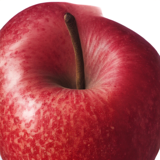

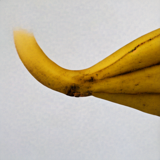

In [6]:
!pip -q install diffusers
from diffusers import AutoPipelineForText2Image

t2i = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
t2i = t2i.to("cuda" if torch.cuda.is_available() else "cpu")

classes = {"apple":  "a photo of a single red apple on a white background",
           "banana": "a photo of a single yellow banana on a white background"}

images = []
for label, prompt in classes.items():
    for _ in range(3):                                       # 2 classes x 3 = 6 images
        im = t2i(prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
        images.append((im, label))

print("generated", len(images), "labelled images")
from IPython.display import display
display(images[0][0].resize((160, 160)), images[3][0].resize((160, 160)))
free_memory(t2i)

## 4 · Audio — text → speech (TTS)

**`microsoft/speecht5_tts`** turns text into speech; a *speaker embedding* fixes the voice.
Generating short words builds a tiny **spoken-keyword** dataset (label known by construction).

In [7]:
!pip -q install datasets soundfile
from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
from IPython.display import Audio, display

tts = pipeline("text-to-speech", model="microsoft/speecht5_tts")

# A fixed voice from a standard speaker-embedding set (with a safe fallback).
try:
    emb = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")
    speaker = torch.tensor(emb[7306]["xvector"]).unsqueeze(0)
except Exception as e:
    print("x-vector dataset unavailable, using a fixed pseudo-random voice:", e)
    g = torch.Generator().manual_seed(0)
    speaker = torch.randn(1, 512, generator=g)
    speaker = speaker / speaker.norm()

words, clips = ["yes", "no", "up", "down"], []
for w in words:
    out = tts(w, forward_params={"speaker_embeddings": speaker})
    sf.write(f"{w}.wav", out["audio"], out["sampling_rate"])
    clips.append((f"{w}.wav", w))                    # (file, label)

print("wrote", len(clips), "labelled clips")
display(Audio(f"{words[0]}.wav"))
free_memory(tts)

config.json:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  585MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  585MB            

...

README.md:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 50.6MB            

model.safetensors: downloading bytes:           |  0.00B            

cmu-arctic-xvectors.py:   0%|          | 0.00/1.36k [00:00<?, ?B/s]

x-vector dataset unavailable, using a fixed pseudo-random voice: Dataset scripts are no longer supported, but found cmu-arctic-xvectors.py
wrote 4 labelled clips


### A first *peek*: TSTR on the text data

**TSTR = Train on Synthetic, Test on Real.** If a model trained *only* on our synthetic reviews
does well on **real** held-out reviews, the synthetic data carried real signal.

> **Caveat:** four real points is only a demo. Proper TSTR + metrics = **Lecture 7**.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

real = [("These earbuds sound amazing and fit perfectly.", "positive"),
        ("The coffee maker leaked and died in a week.",     "negative"),
        ("Super comfortable shoes, great for long runs.",   "positive"),
        ("The laptop stand is flimsy and wobbles a lot.",   "negative")]
Xr, yr = zip(*real)

clf = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
clf.fit(df_text["text"], df_text["label"])          # TRAIN on synthetic
print("TSTR accuracy on real:", clf.score(Xr, yr))

TSTR accuracy on real: 0.5


## 5 · What to observe & discuss
* **Text:** how repetitive is output *without* the attribute grid? Try removing it.
* **Tabular:** how many generations were invalid JSON? Any impossible values slipped through?
* **Image:** are the two classes visually distinct? Any odd artefacts?
* **Audio:** are the spoken words intelligible? How would you add within-class variety? *(hint: more speakers)*
* Which **biases** appear (countries, spending, voices), and where might they come from?

### Stretch goals
* Add a **persona** field to the text prompt and measure the diversity gain.
* Grow the image/audio sets (more classes/speakers) for use in the **Lecture 3 workshop**.
* Compare a purely-synthetic classifier against **real + synthetic**.

---
*Next: Lecture 3 — Workshop. You combine augmentation and generation across modalities and
**evaluate properly** with the tools from Lecture 7.*